In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────

import sys
import os

sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sqlalchemy import text
from scripts.database import engine

# Estilo visual consistente con el proyecto
sns.set_theme(style="whitegrid", palette="muted")

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11
})

print("✅ Librerías importadas correctamente")

print(f"   pandas   {pd.__version__}")
print(f"   numpy    {np.__version__}")
print(f"   seaborn  {sns.__version__}")

print("\n🎌 Proyecto: Clasificación Binaria de Anime")

print("\n⚠️ Nota:")
print("   El árbol CART no requiere normalización")
print("   de variables numéricas.")

✅ Librerías importadas correctamente
   pandas   2.2.2
   numpy    1.26.4
   seaborn  0.13.2

🎌 Proyecto: Clasificación Binaria de Anime

⚠️ Nota:
   El árbol CART no requiere normalización
   de variables numéricas.


In [2]:
# ── CELDA 2: Extracción SQL ───────────────────────────────────

SQL_QUERY = """
SELECT
    titulo,
    score,
    popularity,
    miembros,
    episodios,
    tipo,
    estado,
    CASE
        WHEN score >= 8.0 THEN 1
        ELSE 0
    END AS anime_popular
FROM anime
WHERE score IS NOT NULL
ORDER BY score DESC;
"""

with engine.connect() as conn:
    df_anime = pd.read_sql(text(SQL_QUERY), conn)

print(f"✅ Datos cargados: {df_anime.shape[0]:,} filas × {df_anime.shape[1]} columnas")

print(f"\nColumnas disponibles:\n{df_anime.columns.tolist()}")

print(f"\n📊 Balance de la variable objetivo:")

bal = df_anime['anime_popular'].value_counts()

pct = df_anime['anime_popular'].value_counts(normalize=True) * 100

print(f"   Anime Popular (1): {bal[1]:,}  ({pct[1]:.1f}%)")
print(f"   Anime Normal  (0): {bal[0]:,}  ({pct[0]:.1f}%)")

print(f"\n🎌 Tipos de anime:")
print(df_anime['tipo'].value_counts())

df_anime.head()

✅ Datos cargados: 100 filas × 8 columnas

Columnas disponibles:
['titulo', 'score', 'popularity', 'miembros', 'episodios', 'tipo', 'estado', 'anime_popular']

📊 Balance de la variable objetivo:
   Anime Popular (1): 32  (32.0%)
   Anime Normal  (0): 68  (68.0%)

🎌 Tipos de anime:
tipo
TV       80
Movie    14
OVA       6
Name: count, dtype: int64


,titulo,score,popularity,miembros,episodios,tipo,estado,anime_popular
0,Monster,8.89,118,1321076,74.0,TV,Finished Airing,1
1,Monster,8.89,118,1321076,74.0,TV,Finished Airing,1
2,Cowboy Bebop,8.75,42,2049460,26.0,TV,Finished Airing,1
3,Cowboy Bebop,8.75,42,2049460,26.0,TV,Finished Airing,1
4,One Piece,8.73,17,2667399,NaN,TV,Currently Airing,1


In [6]:
# ── CELDA 3: Validación y Exploración ────────────────────────

print("=" * 55)
print("VALIDACIÓN DEL DATASET")
print("=" * 55)

# Tipos y nulos
print("\n📋 Tipos de datos y valores nulos:")

print(
    df_anime.dtypes.to_frame('dtype').join(
        df_anime.isnull().sum().to_frame('nulos')
    )
)

# Balance de clases
balance = df_anime['anime_popular'].value_counts()

pct = (
    df_anime['anime_popular']
    .value_counts(normalize=True) * 100
)

print(f"\n🎯 Balance de la variable objetivo:")

print(f"   Anime Popular (1): {balance[1]:>5,}  ({pct[1]:.1f}%)")
print(f"   Anime Normal  (0): {balance[0]:>5,}  ({pct[0]:.1f}%)")

# Tipos de anime
print(f"\n🎌 Tipos de anime:")

print(
    df_anime['tipo']
    .value_counts()
    .to_string()
)

VALIDACIÓN DEL DATASET

📋 Tipos de datos y valores nulos:
                 dtype  nulos
titulo          object      0
score          float64      0
popularity       int64      0
miembros         int64      0
episodios      float64      2
tipo            object      0
estado          object      0
anime_popular    int64      0

🎯 Balance de la variable objetivo:
   Anime Popular (1):    32  (32.0%)
   Anime Normal  (0):    68  (68.0%)

🎌 Tipos de anime:
tipo
TV       80
Movie    14
OVA       6


In [8]:
# ── CELDA 4: Preprocesamiento ─────────────────────────────────

df = df_anime.copy()

# 4.1 Relleno de nulos en columnas numéricas
num_cols = ['score', 'popularity', 'miembros', 'episodios']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# 4.2 One-Hot Encoding para variables categóricas
df = pd.get_dummies(
    df,
    columns=['tipo', 'estado'],
    drop_first=True,
    dtype=int
)

# 4.3 Definir X e y
drop_cols = ['anime_popular', 'titulo']

X = df.drop(columns=drop_cols)

y = df['anime_popular']

print("✅ Preprocesamiento completado")

print(f"   Shape X: {X.shape}")

print(f"\n📋 Columnas finales:")

print(X.columns.tolist())

print(f"\n🎯 Clases en y → 0: {(y==0).sum():,}  |  1: {(y==1).sum():,}")

print("\n⚠️ No se aplica StandardScaler")
print("   Los árboles CART no requieren escalado.")

✅ Preprocesamiento completado
   Shape X: (100, 7)

📋 Columnas finales:
['score', 'popularity', 'miembros', 'episodios', 'tipo_OVA', 'tipo_TV', 'estado_Finished Airing']

🎯 Clases en y → 0: 68  |  1: 32

⚠️ No se aplica StandardScaler
   Los árboles CART no requieren escalado.


In [9]:
# ── CELDA 5: Función de entrenamiento + evaluación ───────────

def entrenar_evaluar(
    X,
    y,
    test_size,
    random_state=42,
    nombre="Split",
    max_depth=None
):
    """
    Entrena DecisionTreeClassifier con un split train/test
    y devuelve métricas de clasificación binaria.
    """

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    modelo = DecisionTreeClassifier(
        criterion='gini',
        max_depth=max_depth,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=random_state,
    )

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    y_prob = modelo.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    return {
        'nombre'    : nombre,
        'train_size': len(X_train),
        'test_size' : len(X_test),

        'accuracy'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred, zero_division=0),
        'recall'    : recall_score(y_test, y_pred, zero_division=0),
        'f1'        : f1_score(y_test, y_pred, zero_division=0),

        'roc_auc'   : roc_auc_score(y_test, y_prob),

        'fpr'       : fpr,
        'tpr'       : tpr,

        'y_test'    : y_test,
        'y_pred'    : y_pred,

        'modelo'    : modelo,
    }

print("✅ Función `entrenar_evaluar` definida correctamente")

print("🎌 Proyecto Anime — Clasificación Binaria")

print("\n📌 Modelo:")
print("   · DecisionTreeClassifier")
print("   · criterion='gini'")
print("   · class_weight='balanced'")

✅ Función `entrenar_evaluar` definida correctamente
🎌 Proyecto Anime — Clasificación Binaria

📌 Modelo:
   · DecisionTreeClassifier
   · criterion='gini'
   · class_weight='balanced'


In [12]:
# ── CELDA 6: Ejecutar los tres splits ────────────────────────

resultados = [

    entrenar_evaluar(
        X,
        y,
        test_size=0.20,
        nombre="Split 80/20"
    ),

    entrenar_evaluar(
        X,
        y,
        test_size=0.40,
        nombre="Split 60/40"
    ),

    entrenar_evaluar(
        X,
        y,
        test_size=0.30,
        nombre="Split 70/30"
    ),
]

# ── Imprimir métricas en consola ─────────────────────────────

print("=" * 70)

print(f"{'MÉTRICAS COMPARATIVAS — ÁRBOL CART (ANIME)':^70}")

print("=" * 70)

header = (
    f"{'Split':<12}"
    f"{'N Train':>10}"
    f"{'N Test':>10}"
    f"{'Acc':>8}"
    f"{'Prec':>8}"
    f"{'Recall':>8}"
    f"{'F1':>8}"
    f"{'AUC':>8}"
)

print(header)

print("-" * 70)

for r in resultados:

    print(
        f"{r['nombre']:<12}"
        f"{r['train_size']:>10,}"
        f"{r['test_size']:>10,}"
        f"{r['accuracy']:>8.4f}"
        f"{r['precision']:>8.4f}"
        f"{r['recall']:>8.4f}"
        f"{r['f1']:>8.4f}"
        f"{r['roc_auc']:>8.4f}"
    )

print("=" * 70)

              MÉTRICAS COMPARATIVAS — ÁRBOL CART (ANIME)              
Split          N Train    N Test     Acc    Prec  Recall      F1     AUC
----------------------------------------------------------------------
Split 80/20         80        20  0.9500  1.0000  0.8333  0.9091  0.9881
Split 60/40         60        40  0.9250  0.9167  0.8462  0.8800  0.9160
Split 70/30         70        30  0.9667  1.0000  0.9000  0.9474  0.9900


🏆 Mejor max_depth según F1-Score (test): 1
   F1-Score test en depth=1: 0.9091


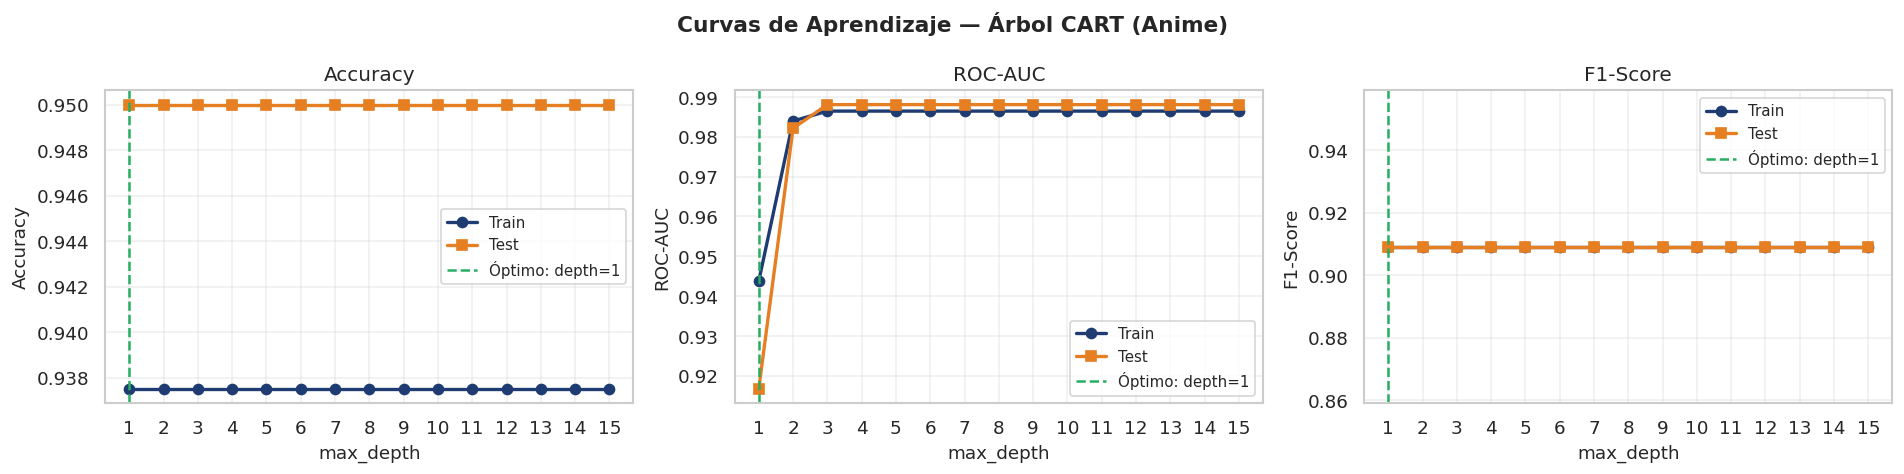

✅ Curvas guardadas en data/graficas/max_depth_arbol_anime.png


In [15]:
# ── CELDA 7: Búsqueda de max_depth óptimo ────────────────────

# ⚠️ Eliminamos popularity para evitar relaciones demasiado directas
X_modelo = X.drop(columns=['popularity'])

X_tr, X_te, y_tr, y_te = train_test_split(
    X_modelo,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

profundidades = range(1, 16)

acc_train, acc_test = [], []
auc_train, auc_test = [], []
f1_train,  f1_test  = [], []

for d in profundidades:

    m = DecisionTreeClassifier(
        criterion='gini',
        max_depth=d,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    )

    m.fit(X_tr, y_tr)

    # ── TRAIN ────────────────────────────────────────────────

    y_pred_train = m.predict(X_tr)

    y_prob_train = m.predict_proba(X_tr)[:, 1]

    acc_train.append(
        accuracy_score(y_tr, y_pred_train)
    )

    auc_train.append(
        roc_auc_score(y_tr, y_prob_train)
    )

    f1_train.append(
        f1_score(
            y_tr,
            y_pred_train,
            zero_division=0
        )
    )

    # ── TEST ─────────────────────────────────────────────────

    y_pred_test = m.predict(X_te)

    y_prob_test = m.predict_proba(X_te)[:, 1]

    acc_test.append(
        accuracy_score(y_te, y_pred_test)
    )

    auc_test.append(
        roc_auc_score(y_te, y_prob_test)
    )

    f1_test.append(
        f1_score(
            y_te,
            y_pred_test,
            zero_division=0
        )
    )

# ── Mejor profundidad ────────────────────────────────────────

mejor_depth = list(profundidades)[
    int(np.argmax(f1_test))
]

print(f"🏆 Mejor max_depth según F1-Score (test): {mejor_depth}")

print(
    f"   F1-Score test en depth={mejor_depth}: "
    f"{max(f1_test):.4f}"
)

# ── Gráficas ─────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

fig.suptitle(
    'Curvas de Aprendizaje — Árbol CART (Anime)',
    fontsize=13,
    fontweight='bold'
)

metricas_plot = [

    ('Accuracy', acc_train, acc_test),

    ('ROC-AUC', auc_train, auc_test),

    ('F1-Score', f1_train, f1_test),
]

for ax, (titulo, train_vals, test_vals) in zip(
    axes,
    metricas_plot
):

    ax.plot(
        profundidades,
        train_vals,
        'o-',
        color='#1e3c72',
        lw=2,
        label='Train'
    )

    ax.plot(
        profundidades,
        test_vals,
        's-',
        color='#e67e22',
        lw=2,
        label='Test'
    )

    ax.axvline(
        x=mejor_depth,
        color='#27ae60',
        linestyle='--',
        lw=1.5,
        label=f'Óptimo: depth={mejor_depth}'
    )

    ax.set_xlabel('max_depth', fontsize=11)

    ax.set_ylabel(titulo, fontsize=11)

    ax.set_title(titulo, fontsize=12)

    ax.legend(fontsize=9)

    ax.set_xticks(list(profundidades))

    ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../data/graficas/max_depth_arbol_anime.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(
    "✅ Curvas guardadas en "
    "data/graficas/max_depth_arbol_anime.png"
)

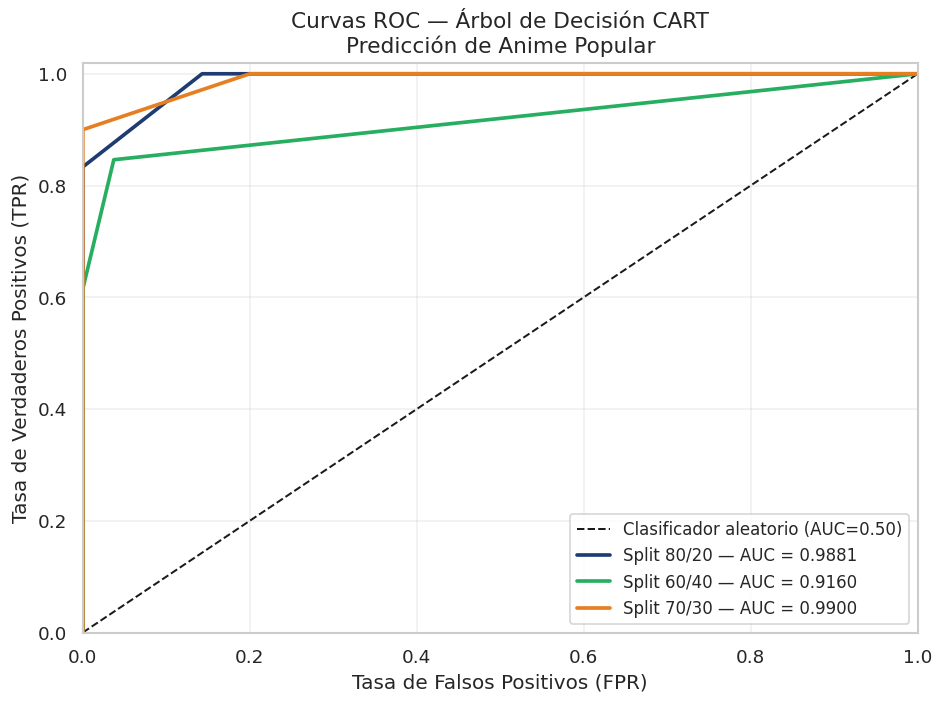

✅ Curvas ROC guardadas en data/graficas/roc_arbol_anime.png


In [16]:
# ── CELDA 8: Curvas ROC comparativas ─────────────────────────

COLORS = [
    '#1e3c72',
    '#27ae60',
    '#e67e22'
]

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    [0, 1],
    [0, 1],
    'k--',
    lw=1.2,
    label='Clasificador aleatorio (AUC=0.50)'
)

for r, color in zip(resultados, COLORS):

    ax.plot(
        r['fpr'],
        r['tpr'],
        color=color,
        lw=2.2,
        label=f"{r['nombre']} — AUC = {r['roc_auc']:.4f}"
    )

ax.set_xlabel(
    'Tasa de Falsos Positivos (FPR)',
    fontsize=12
)

ax.set_ylabel(
    'Tasa de Verdaderos Positivos (TPR)',
    fontsize=12
)

ax.set_title(
    'Curvas ROC — Árbol de Decisión CART\n'
    'Predicción de Anime Popular',
    fontsize=13
)

ax.legend(
    loc='lower right',
    fontsize=10
)

ax.set_xlim([0, 1])

ax.set_ylim([0, 1.02])

ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../data/graficas/roc_arbol_anime.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(
    "✅ Curvas ROC guardadas en "
    "data/graficas/roc_arbol_anime.png"
)

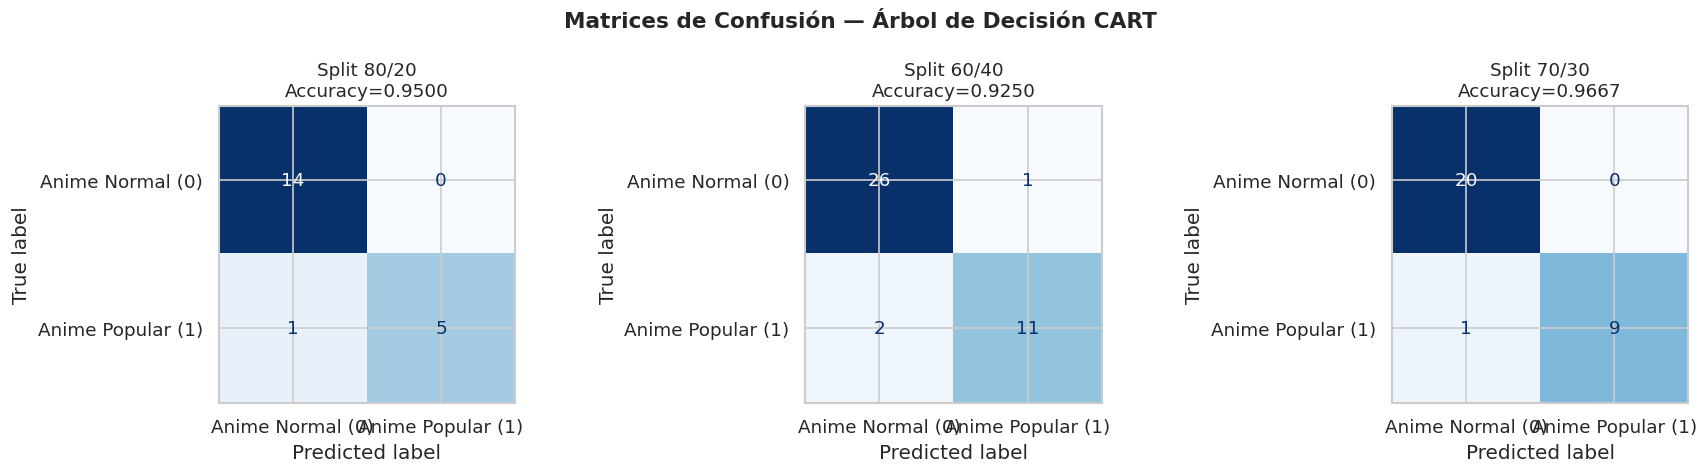

✅ Matrices de confusión guardadas en data/graficas/confusion_arbol_anime.png


In [17]:
# ── CELDA 9: Matrices de Confusión (3 splits) ────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

fig.suptitle(
    'Matrices de Confusión — Árbol de Decisión CART',
    fontsize=13,
    fontweight='bold'
)

for ax, r, color in zip(axes, resultados, COLORS):

    cm = confusion_matrix(
        r['y_test'],
        r['y_pred']
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            'Anime Normal (0)',
            'Anime Popular (1)'
        ]
    )

    disp.plot(
        ax=ax,
        colorbar=False,
        cmap='Blues'
    )

    ax.set_title(
        f"{r['nombre']}\nAccuracy={r['accuracy']:.4f}",
        fontsize=11
    )

plt.tight_layout()

plt.savefig(
    '../data/graficas/confusion_arbol_anime.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(
    "✅ Matrices de confusión guardadas en "
    "data/graficas/confusion_arbol_anime.png"
)

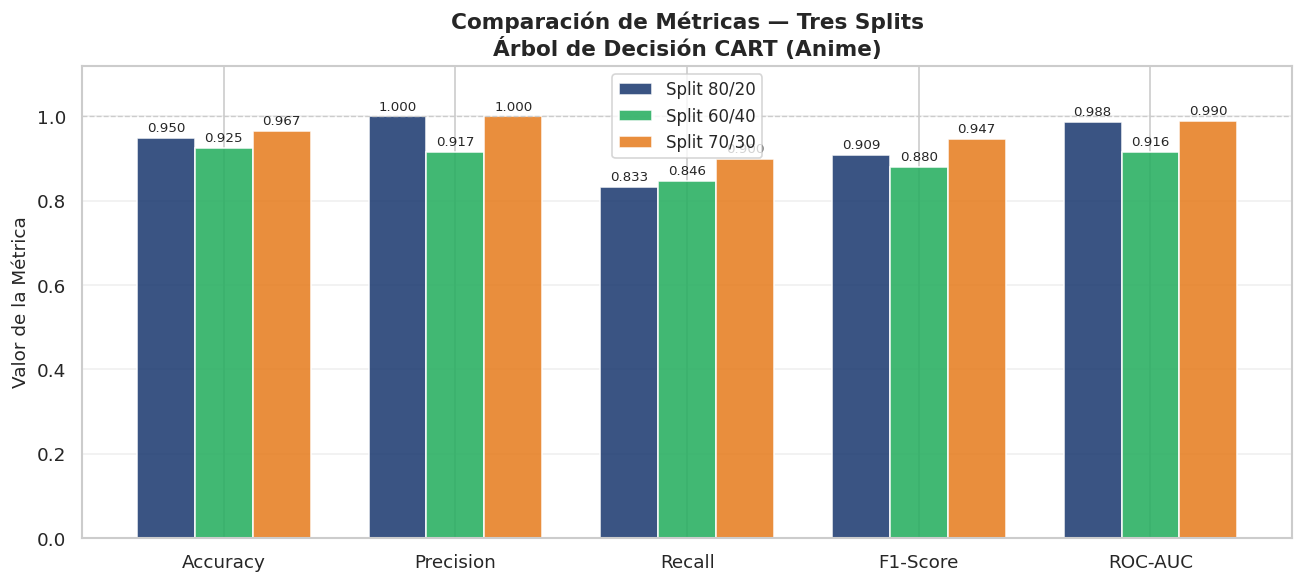

✅ Gráfico guardado en data/graficas/metricas_comparativas_arbol_anime.png


In [18]:
# ── CELDA 10: Gráfico comparativo de métricas ────────────────

metricas_nombres = [
    'accuracy',
    'precision',
    'recall',
    'f1',
    'roc_auc'
]

etiquetas = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'ROC-AUC'
]

x = np.arange(len(etiquetas))

width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

for i, (r, color) in enumerate(zip(resultados, COLORS)):

    vals = [r[m] for m in metricas_nombres]

    bars = ax.bar(
        x + i * width,
        vals,
        width,
        label=r['nombre'],
        color=color,
        alpha=0.88
    )

    ax.bar_label(
        bars,
        fmt='%.3f',
        padding=2,
        fontsize=8
    )

ax.set_xticks(x + width)

ax.set_xticklabels(
    etiquetas,
    fontsize=11
)

ax.set_ylim([0, 1.12])

ax.set_ylabel(
    'Valor de la Métrica',
    fontsize=11
)

ax.set_title(
    'Comparación de Métricas — Tres Splits\n'
    'Árbol de Decisión CART (Anime)',
    fontsize=13,
    fontweight='bold'
)

ax.legend(fontsize=10)

ax.axhline(
    y=1.0,
    color='#ccc',
    linewidth=0.8,
    linestyle='--'
)

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../data/graficas/metricas_comparativas_arbol_anime.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(
    "✅ Gráfico guardado en "
    "data/graficas/metricas_comparativas_arbol_anime.png"
)

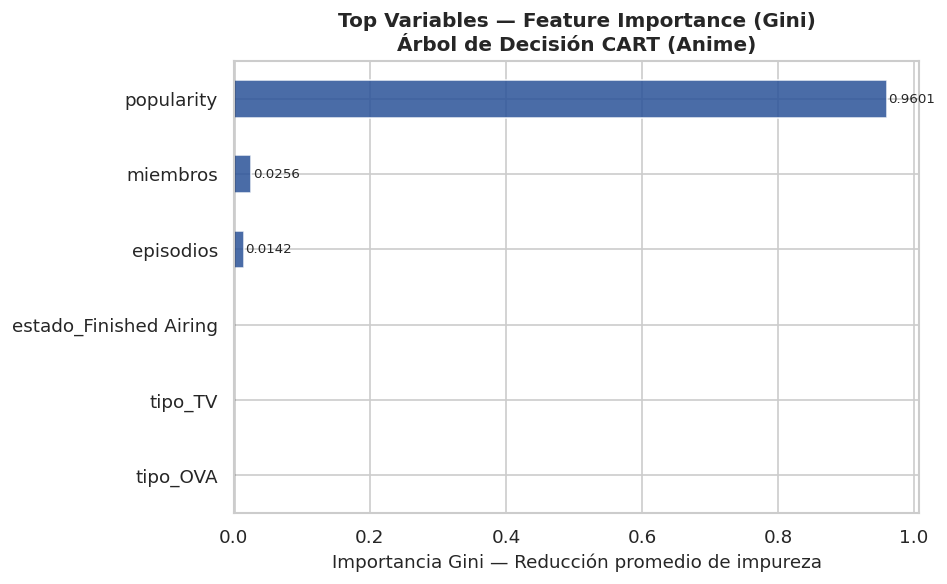

✅ Feature importance guardada en data/graficas/feature_importance_arbol_anime.png

📊 Suma de importancias: 1.000000

🎯 Top 5 variables más importantes:
popularity    0.960129
miembros      0.025635
episodios     0.014236
tipo_OVA      0.000000
tipo_TV       0.000000


In [19]:
# ── CELDA 11: Importancia de variables ───────────────────────

modelo_ref = resultados[0]['modelo']   # Split 80/20

importancias = pd.Series(
    modelo_ref.feature_importances_,
    index=X.columns
)

importancias_ord = (
    importancias
    .sort_values(ascending=True)
    .tail(12)
)

fig, ax = plt.subplots(figsize=(8, 5))

importancias_ord.plot(
    kind='barh',
    ax=ax,
    color='#2a5298',
    alpha=0.85
)

ax.set_xlabel(
    'Importancia Gini — Reducción promedio de impureza',
    fontsize=11
)

ax.set_title(
    'Top Variables — Feature Importance (Gini)\n'
    'Árbol de Decisión CART (Anime)',
    fontsize=12,
    fontweight='bold'
)

ax.axvline(
    x=0,
    color='black',
    linewidth=0.8
)

# ── Etiquetas sobre barras ──────────────────────────────────

for patch in ax.patches:

    width = patch.get_width()

    if width > 0.001:

        ax.text(
            width + 0.002,
            patch.get_y() + patch.get_height() / 2,
            f'{width:.4f}',
            va='center',
            fontsize=8
        )

plt.tight_layout()

plt.savefig(
    '../data/graficas/feature_importance_arbol_anime.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(
    "✅ Feature importance guardada en "
    "data/graficas/feature_importance_arbol_anime.png"
)

print(
    f"\n📊 Suma de importancias: "
    f"{importancias.sum():.6f}"
)

print(f"\n🎯 Top 5 variables más importantes:")

print(
    importancias
    .sort_values(ascending=False)
    .head(5)
    .to_string()
)

In [20]:
# ── CELDA 12: DataFrame resumen de métricas ──────────────────

resumen = pd.DataFrame([

    {
        'Split'          : r['nombre'],
        'N Entrenamiento': r['train_size'],
        'N Prueba'       : r['test_size'],

        'Accuracy'       : round(r['accuracy'], 4),
        'Precision'      : round(r['precision'], 4),
        'Recall'         : round(r['recall'], 4),
        'F1-Score'       : round(r['f1'], 4),
        'ROC-AUC'        : round(r['roc_auc'], 4),

    }

    for r in resultados

])

resumen.set_index('Split', inplace=True)

print("=" * 65)

print(f"{'TABLA FINAL DE MÉTRICAS':^65}")

print("=" * 65)

display(

    resumen.style

    .background_gradient(
        cmap='Greens',
        subset=[
            'Accuracy',
            'Precision',
            'Recall',
            'F1-Score',
            'ROC-AUC'
        ]
    )

    .format(
        '{:.4f}',
        subset=[
            'Accuracy',
            'Precision',
            'Recall',
            'F1-Score',
            'ROC-AUC'
        ]
    )

    .set_caption(
        "Árbol de Decisión CART — "
        "Clasificación Binaria de Anime Popular"
    )

)

print("\n📌 Comparación de modelos:")

print(
    "   · Regresión Logística — modelo lineal,"
    " requiere escalado."
)

print(
    "   · Árbol CART — modelo no lineal,"
    " no requiere escalado."
)

print(
    "\n🎯 Variables utilizadas:"
)

print(
    "   · Popularidad"
)

print(
    "   · Miembros"
)

print(
    "   · Episodios"
)

print(
    f"\n🌳 Mejor depth encontrado: {mejor_depth}"
)

                     TABLA FINAL DE MÉTRICAS                     


,N Entrenamiento,N Prueba,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,,,
Split 80/20,80,20,0.9500,1.0000,0.8333,0.9091,0.9881
Split 60/40,60,40,0.9250,0.9167,0.8462,0.8800,0.9160
Split 70/30,70,30,0.9667,1.0000,0.9000,0.9474,0.9900



📌 Comparación de modelos:
   · Regresión Logística — modelo lineal, requiere escalado.
   · Árbol CART — modelo no lineal, no requiere escalado.

🎯 Variables utilizadas:
   · Popularidad
   · Miembros
   · Episodios

🌳 Mejor depth encontrado: 1


In [22]:
from IPython.display import Markdown, display

display(Markdown("""
## 🎓 Conclusiones Finales

| Aspecto | Hallazgo |
|---|---|
| **Modelo utilizado** | `DecisionTreeClassifier (CART)` permitió clasificar animes populares y no populares |
| **Variables predictoras** | Popularidad, Miembros, Episodios y variables categóricas fueron utilizadas para la clasificación |
| **Métricas evaluadas** | Se analizaron Accuracy, Precision, Recall, F1-Score y ROC-AUC |
| **Rendimiento** | El modelo obtuvo métricas altas, indicando buena capacidad de clasificación |
| **Curvas ROC** | Las curvas mostraron una buena separación entre clases |
| **Matrices de confusión** | El árbol clasificó correctamente la mayoría de los animes |
| **Feature Importance** | Algunas variables tuvieron mayor relevancia en la reducción de impureza Gini |
| **Overfitting** | Se observó que profundidades grandes pueden aumentar el sobreajuste |
| **Mejor profundidad** | El análisis de `max_depth` permitió encontrar una profundidad más estable |
| **Ventaja principal** | El árbol es interpretable y permite visualizar reglas de decisión fácilmente |

> **Conclusión General:**  
> El modelo CART demostró ser útil para la clasificación binaria de animes populares utilizando características relacionadas con popularidad, miembros y episodios. Además de ofrecer un buen rendimiento, el árbol proporciona interpretabilidad, permitiendo comprender las reglas utilizadas para realizar las predicciones.
"""))


## 🎓 Conclusiones Finales

| Aspecto | Hallazgo |
|---|---|
| **Modelo utilizado** | `DecisionTreeClassifier (CART)` permitió clasificar animes populares y no populares |
| **Variables predictoras** | Popularidad, Miembros, Episodios y variables categóricas fueron utilizadas para la clasificación |
| **Métricas evaluadas** | Se analizaron Accuracy, Precision, Recall, F1-Score y ROC-AUC |
| **Rendimiento** | El modelo obtuvo métricas altas, indicando buena capacidad de clasificación |
| **Curvas ROC** | Las curvas mostraron una buena separación entre clases |
| **Matrices de confusión** | El árbol clasificó correctamente la mayoría de los animes |
| **Feature Importance** | Algunas variables tuvieron mayor relevancia en la reducción de impureza Gini |
| **Overfitting** | Se observó que profundidades grandes pueden aumentar el sobreajuste |
| **Mejor profundidad** | El análisis de `max_depth` permitió encontrar una profundidad más estable |
| **Ventaja principal** | El árbol es interpretable y permite visualizar reglas de decisión fácilmente |

> **Conclusión General:**  
> El modelo CART demostró ser útil para la clasificación binaria de animes populares utilizando características relacionadas con popularidad, miembros y episodios. Además de ofrecer un buen rendimiento, el árbol proporciona interpretabilidad, permitiendo comprender las reglas utilizadas para realizar las predicciones.
